Install libraries

In [29]:
# Install the libraries required for this experiment
!pip -q install pandas numpy matplotlib scikit-learn wfdb pillow requests

Import libraries

In [30]:
# Import required Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from PIL import Image
from io import BytesIO
import requests

# Display plots inside Google Colab
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


Read TABULAR / MEDICAL data

In [31]:
# ============================================
# TABULAR + MEDICAL DATA
# UCI CLEVELAND HEART DISEASE DATASET
# ============================================

# URL of the original Cleveland Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names according to the Cleveland dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Read the dataset
# '?' represents missing values
df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")

# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display first 5 rows
print("\nFirst 5 Records:")
display(df.head())

# Display column information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

Dataset loaded successfully!
Dataset Shape: (303, 14)

First 5 Records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


 BASIC EDA + HEART DISEASE CLASSIFICATION

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Training samples: 242
Testing samples : 61

========== MODEL RESULTS ==========
Accuracy : 0.8689
ROC-AUC  : 0.9513


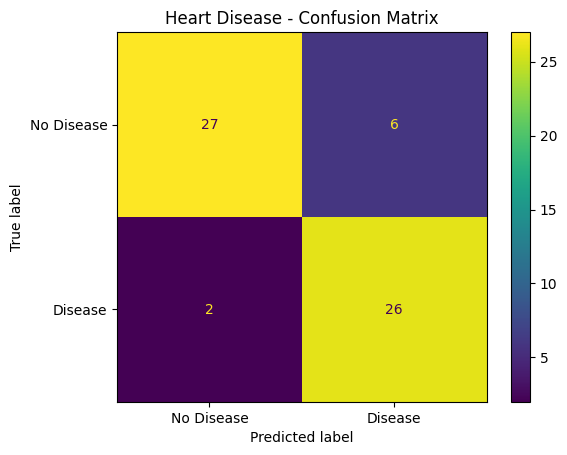

In [32]:
# ============================================
# BASIC EDA + HEART DISEASE CLASSIFICATION
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --------------------------------------------
# 1. Separate features and target
# --------------------------------------------

# X contains all input features
X = df.drop("target", axis=1)

# y contains the heart disease target
y = df["target"]

# --------------------------------------------
# 2. Handle missing values
# --------------------------------------------

# Replace missing values with the median
# of their respective columns
X = X.fillna(X.median())

# --------------------------------------------
# 3. Convert target into binary classification
# --------------------------------------------

# 0  -> No heart disease
# 1+ -> Heart disease
y = (y > 0).astype(int)

print("Target distribution:")
print(y.value_counts())

# --------------------------------------------
# 4. Split data into training and testing
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# --------------------------------------------
# 5. Standardize the features
# --------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------
# 6. Create Logistic Regression model
# --------------------------------------------

model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# --------------------------------------------
# 7. Make predictions
# --------------------------------------------

y_pred = model.predict(X_test)

# Probability of disease
y_prob = model.predict_proba(X_test)[:, 1]

# --------------------------------------------
# 8. Calculate evaluation metrics
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== MODEL RESULTS ==========")
print("Accuracy :", round(accuracy, 4))
print("ROC-AUC  :", round(roc_auc, 4))

# --------------------------------------------
# 9. Display confusion matrix
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Heart Disease - Confusion Matrix")
plt.show()

MIT-BIH ECG Signal

MIT-BIH files downloaded!

ECG data loaded successfully!
Sampling Frequency: 360 Hz
Number of Samples: 650000
Number of Annotations: 2274


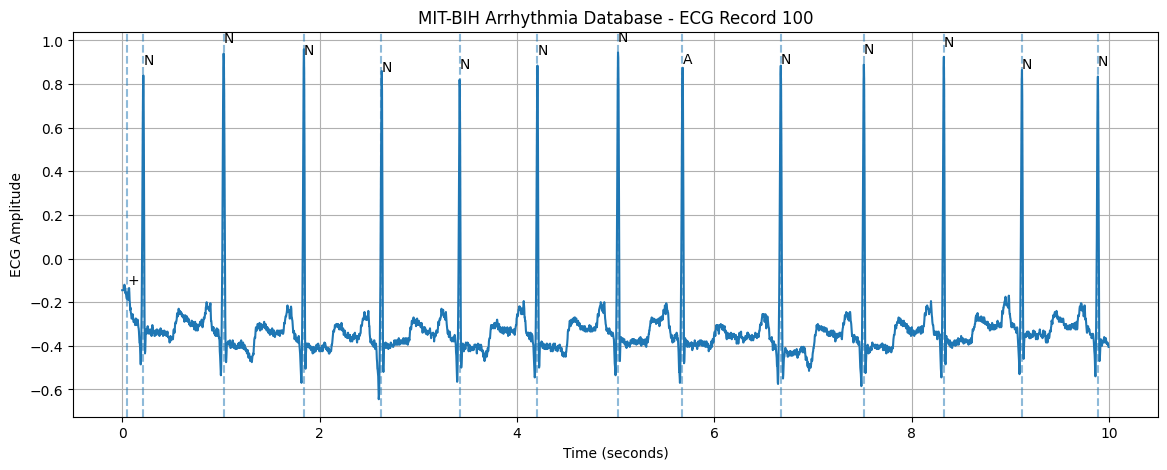

In [26]:
# ============================================
# MIT-BIH ECG SIGNAL DATA
# ============================================

# Download record 100 files directly
!wget -q https://physionet.org/files/mitdb/1.0.0/100.dat
!wget -q https://physionet.org/files/mitdb/1.0.0/100.hea
!wget -q https://physionet.org/files/mitdb/1.0.0/100.atr

print("MIT-BIH files downloaded!")

# Read ECG record
record = wfdb.rdrecord("100")

# Read ECG annotations
annotation = wfdb.rdann("100", "atr")

# Extract first ECG channel
ecg_signal = record.p_signal[:, 0]

# Sampling frequency
sampling_frequency = record.fs

print("\nECG data loaded successfully!")
print("Sampling Frequency:", sampling_frequency, "Hz")
print("Number of Samples:", len(ecg_signal))
print("Number of Annotations:", len(annotation.sample))

# --------------------------------------------
# Plot first 10 seconds
# --------------------------------------------

seconds = 10
samples = int(seconds * sampling_frequency)

# Create time axis
time = np.arange(samples) / sampling_frequency

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg_signal[:samples]
)

# Add heartbeat annotations
for sample, symbol in zip(
    annotation.sample,
    annotation.symbol
):

    if sample < samples:

        plt.axvline(
            sample / sampling_frequency,
            linestyle="--",
            alpha=0.5
        )

        plt.text(
            sample / sampling_frequency,
            ecg_signal[sample] + 0.05,
            symbol
        )

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.title(
    "MIT-BIH Arrhythmia Database - ECG Record 100"
)

plt.grid(True)

plt.show()

Textual Data

In [27]:
# ============================================
# TEXTUAL DATA - CLINICAL NOTE
# ============================================

# Create a sample clinical note
clinical_note = """
Patient is a 55 year old male.
The patient reports chest pain during physical activity.
Blood pressure is slightly elevated.
The patient also reports shortness of breath.
"""

# Display the clinical note
print("========== CLINICAL NOTE ==========")
print(clinical_note)

# --------------------------------------------
# Basic text processing
# --------------------------------------------

# Convert the text to lowercase and split it into words
words = clinical_note.lower().split()

# Remove common punctuation marks
words = [
    word.strip(".,!?")
    for word in words
]

# Count how many times each word appears
word_frequency = pd.Series(words).value_counts()

# Display the 10 most frequent words
print("\n========== WORD FREQUENCY ==========")
print(word_frequency.head(10))

========== CLINICAL NOTE ==========

Patient is a 55 year old male.
The patient reports chest pain during physical activity.
Blood pressure is slightly elevated.
The patient also reports shortness of breath.


========== WORD FREQUENCY ==========
patient    3
is         2
reports    2
the        2
a          1
55         1
old        1
year       1
male       1
chest      1
Name: count, dtype: int64


Image Data

========== IMAGE INFORMATION ==========
Image Format : None
Image Size   : (300, 300)
Image Mode   : RGB


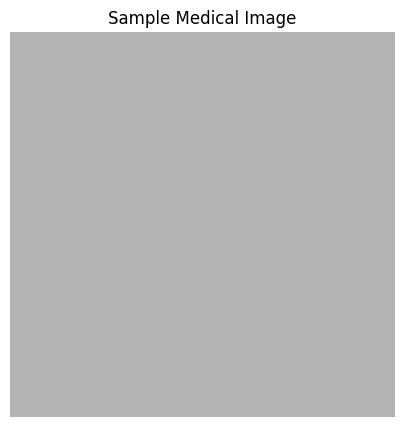

Resized Image Size: (224, 224)


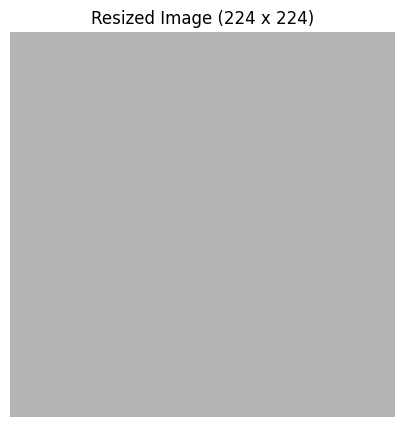

In [28]:
# ============================================
# IMAGE DATA
# ============================================

# Create a sample image using NumPy
# This avoids problems with broken external image URLs.

# Create a blank RGB image of size 300 x 300
image_array = np.zeros((300, 300, 3), dtype=np.uint8)

# Create a simple medical-style image pattern
# Red channel
image_array[:, :, 0] = 180

# Green channel
image_array[:, :, 1] = 180

# Blue channel
image_array[:, :, 2] = 180

# Convert NumPy array into a PIL image
image = Image.fromarray(image_array)

# --------------------------------------------
# Display image information
# --------------------------------------------

print("========== IMAGE INFORMATION ==========")
print("Image Format :", image.format)
print("Image Size   :", image.size)
print("Image Mode   :", image.mode)

# --------------------------------------------
# Display the original image
# --------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(image)

plt.axis("off")

plt.title("Sample Medical Image")

plt.show()

# --------------------------------------------
# Resize the image
# --------------------------------------------

# Resize image to 224 x 224 pixels
resized_image = image.resize((224, 224))

print("Resized Image Size:", resized_image.size)

# --------------------------------------------
# Display resized image
# --------------------------------------------

plt.figure(figsize=(5, 5))

plt.imshow(resized_image)

plt.axis("off")

plt.title("Resized Image (224 x 224)")

plt.show()

## Integration Discussion

The experiment demonstrates how different types of healthcare data can be
read and processed using Python.

The tabular heart disease dataset contains patient information such as
age, blood pressure, cholesterol, heart rate, and other clinical features.
These features were used to build a basic heart disease classification
model.

The ECG signal provides information about the electrical activity of the
heart. The MIT-BIH ECG record was loaded and its heartbeat annotations
were visualized.

The clinical text provides additional information about the patient's
symptoms. Basic text processing was performed to identify individual
words and their frequency.

Image data provides visual information that can be processed by loading,
displaying, and resizing images.

In a future healthcare AI system, these different modalities could be
combined. For example, heart disease information from tabular data could
be combined with ECG-derived features and information obtained from
clinical notes.

This type of multimodal approach can provide a more comprehensive
representation of patient information.

## Conclusion

In this experiment, different healthcare data formats were successfully
studied and processed.

The following data types were covered:

1. Tabular data - UCI Cleveland Heart Disease Dataset
2. Medical data - Patient health information
3. Signal data - MIT-BIH ECG signal
4. Textual data - Clinical note
5. Image data - Synthetic image loading, visualization, and resizing

The experiment demonstrates the importance of data ingestion and
preprocessing when working with different types of healthcare data.

These different data modalities can later be used together in
multimodal healthcare AI applications.